# Практическая работа № 2. Разведочный анализ данных

Выполнил: Эркинбеков Айман  
Вариант: B

## Цель

Посмотреть состав данных, проверить пропуски и необычные значения, построить графики и определить, что нужно подготовить перед обучением модели.

## Данные

Использую Titanic с Kaggle, файл train.csv.

Источник: https://www.kaggle.com/datasets/amineipad/titanic-dataset

Одна строка соответствует одному пассажиру. Целевой столбец Survived показывает, выжил ли пассажир: 0 означает «нет», 1 означает «да».

В этой работе только изучаю данные. Заполнение пропусков, преобразование признаков и обучение модели будут выполнены позже.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "#FAFAFC",
    "axes.facecolor": "#FAFAFC",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
    "grid.alpha": 0.25,
    "axes.axisbelow": True
})

COLORS = ["#4C78A8", "#F28E2B", "#59A14F", "#B279A2", "#E15759"]

pd.set_option("display.max_columns", None)

print("Библиотеки подключены")

Библиотеки подключены


In [2]:
DATA_PATH = Path("../data/train.csv")

print("Рабочая папка:", Path.cwd())

assert DATA_PATH.exists(), f"Не найден файл: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)

display(df.head())
print("Размер таблицы:", df.shape)

expected_columns = {
    "PassengerId", "Survived", "Pclass", "Name",
    "Sex", "Age", "SibSp", "Parch", "Ticket",
    "Fare", "Cabin", "Embarked"
}

assert set(df.columns) == expected_columns, "Проверьте файл и названия столбцов"
assert df.shape == (891, 12), "Версия данных отличается от ожидаемой"

Рабочая папка: /Users/aimanerkinbecovgmail.com/practical-work-1/practical-02/notebooks


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Размер таблицы: (891, 12)


In [3]:
df.info()

summary = pd.DataFrame({
    "Тип в pandas": df.dtypes.astype(str),
    "Пропусков": df.isna().sum(),
    "Пропусков, %": (df.isna().mean() * 100).round(2),
    "Разных значений": df.nunique()
})

display(summary)

print("Полностью повторяющихся строк:", df.duplicated().sum())
print("Повторяющихся PassengerId:", df["PassengerId"].duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,Тип в pandas,Пропусков,"Пропусков, %",Разных значений
PassengerId,int64,0,0.00,891
Survived,int64,0,0.00,2
Pclass,int64,0,0.00,3
Name,str,0,0.00,891
Sex,str,0,0.00,2
Age,float64,177,19.87,88
SibSp,int64,0,0.00,7
Parch,int64,0,0.00,7
Ticket,str,0,0.00,681
Fare,float64,0,0.00,248


Полностью повторяющихся строк: 0
Повторяющихся PassengerId: 0


Пропуски есть в Age, Cabin и Embarked. Больше всего пропусков в Cabin, поэтому заполнять этот столбец обычным значением без дополнительной проверки не стоит. Полных повторов строк и повторов PassengerId нет.

In [4]:
feature_types = pd.DataFrame([
    ["PassengerId", "Идентификатор", "Номер пассажира"],
    ["Survived", "Целевой, бинарный", "Выжил или нет"],
    ["Pclass", "Категориальный, порядковый", "Класс: 1, 2 или 3"],
    ["Name", "Текстовый", "Имя пассажира"],
    ["Sex", "Категориальный, номинальный", "Пол"],
    ["Age", "Числовой, непрерывный", "Возраст в годах"],
    ["SibSp", "Числовой, дискретный", "Число братьев, сестёр и супругов"],
    ["Parch", "Числовой, дискретный", "Число родителей и детей"],
    ["Ticket", "Категориальный, много значений", "Номер билета"],
    ["Fare", "Числовой, непрерывный", "Стоимость билета"],
    ["Cabin", "Категориальный, много значений", "Номер каюты"],
    ["Embarked", "Категориальный, номинальный", "Порт посадки"]
], columns=["Столбец", "Тип по смыслу", "Описание"])

display(feature_types)

,Столбец,Тип по смыслу,Описание
0,PassengerId,Идентификатор,Номер пассажира
1,Survived,"Целевой, бинарный",Выжил или нет
2,Pclass,"Категориальный, порядковый","Класс: 1, 2 или 3"
3,Name,Текстовый,Имя пассажира
4,Sex,"Категориальный, номинальный",Пол
5,Age,"Числовой, непрерывный",Возраст в годах
6,SibSp,"Числовой, дискретный","Число братьев, сестёр и супругов"
7,Parch,"Числовой, дискретный",Число родителей и детей
8,Ticket,"Категориальный, много значений",Номер билета
9,Fare,"Числовой, непрерывный",Стоимость билета


In [5]:
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]
category_cols = ["Pclass", "Sex", "Embarked"]
target = "Survived"

display(df[numeric_cols].describe().round(2))

,Age,Fare,SibSp,Parch
count,714.00,891.00,891.00,891.00
mean,29.70,32.20,0.52,0.38
std,14.53,49.69,1.10,0.81
min,0.42,0.00,0.00,0.00
25%,20.12,7.91,0.00,0.00
50%,28.00,14.45,0.00,0.00
75%,38.00,31.00,1.00,0.00
max,80.00,512.33,8.00,6.00


## Распределения числовых признаков

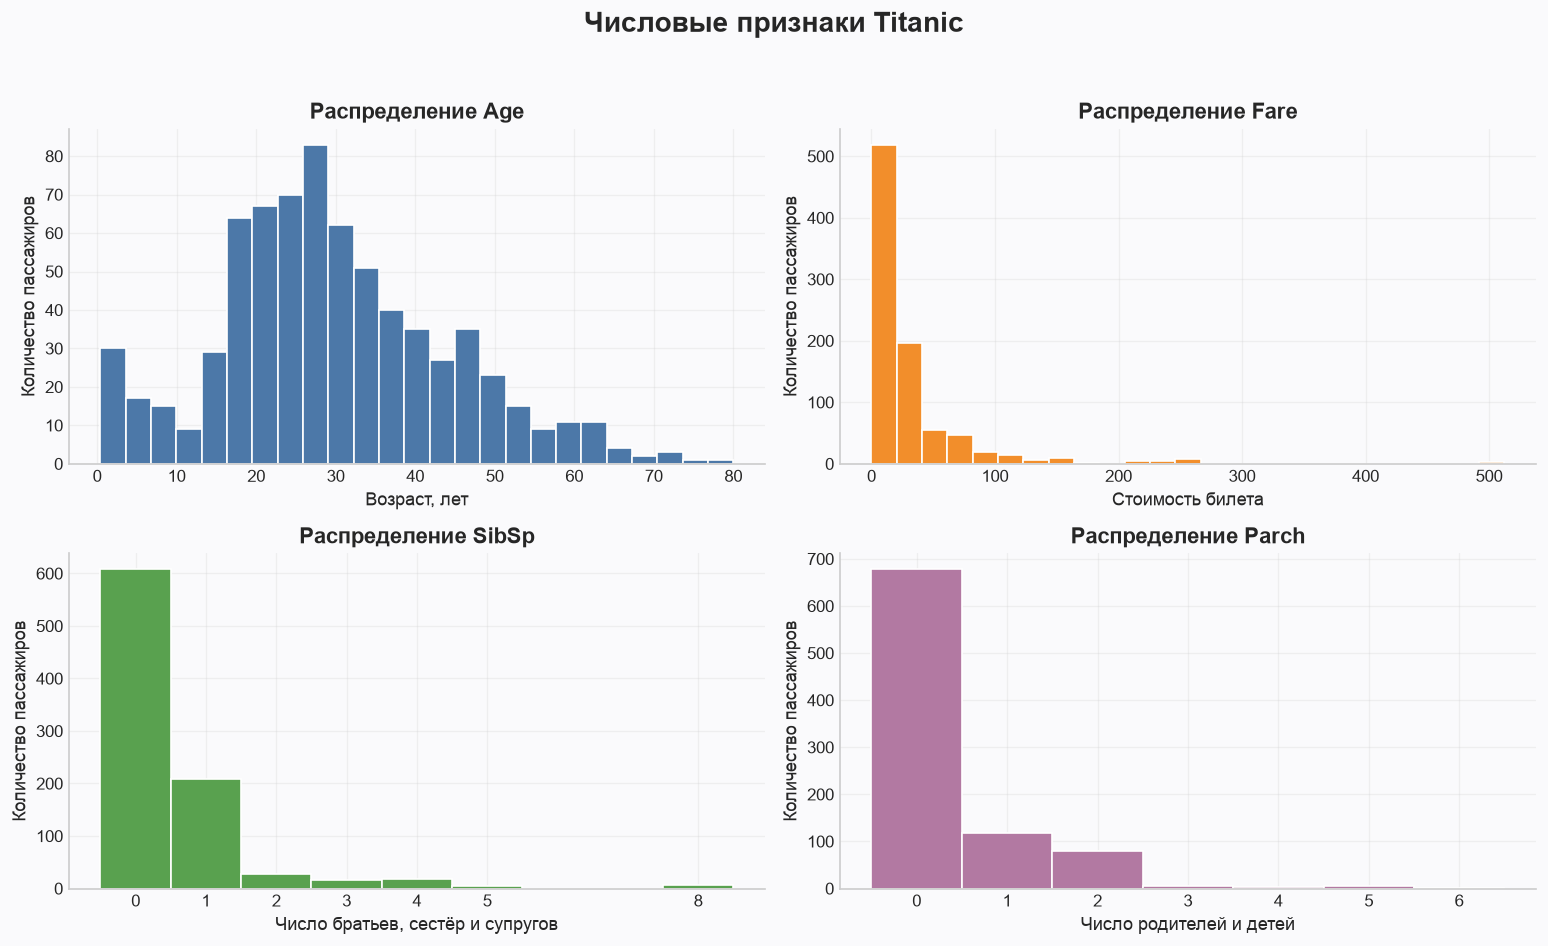

In [6]:
labels = {
    "Age": "Возраст, лет",
    "Fare": "Стоимость билета",
    "SibSp": "Число братьев, сестёр и супругов",
    "Parch": "Число родителей и детей"
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, col, color in zip(axes.ravel(), numeric_cols, COLORS):
    values = df[col].dropna()

    if col in ["SibSp", "Parch"]:
        bins = np.arange(values.min() - 0.5, values.max() + 1.5, 1)
    else:
        bins = 25

    ax.hist(values, bins=bins, color=color, edgecolor="white")
    ax.set_title(f"Распределение {col}")
    ax.set_xlabel(labels[col])
    ax.set_ylabel("Количество пассажиров")

    if col in ["SibSp", "Parch"]:
        ax.set_xticks(sorted(values.unique()))

fig.suptitle("Числовые признаки Titanic", fontsize=17, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Возраст чаще находится примерно между 20 и 40 годами. Распределение стоимости билета сильно скошено вправо: дорогих билетов мало. В SibSp чаще всего встречается 0, то есть пассажир ехал без братьев, сестёр или супруга. В Parch также чаще всего 0, то есть без родителей или детей. Пропуски возраста при построении гистограммы не учитывались.

In [7]:
outlier_rows = []

for col in numeric_cols:
    values = df[col].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (values < lower) | (values > upper)

    outlier_rows.append({
        "Признак": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Нижняя граница": lower,
        "Верхняя граница": upper,
        "За границами": int(mask.sum())
    })

outlier_table = pd.DataFrame(outlier_rows)
display(outlier_table.round(2))

,Признак,Q1,Q3,IQR,Нижняя граница,Верхняя граница,За границами
0,Age,20.12,38.0,17.88,-6.69,64.81,11
1,Fare,7.91,31.0,23.09,-26.72,65.63,116
2,SibSp,0.00,1.0,1.00,-1.50,2.50,46
3,Parch,0.00,0.0,0.00,0.00,0.00,213


/var/folders/l6/pjqjbx3d6nx42v2kf5cnfv180000gn/T/ipykernel_86676/2568664483.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/var/folders/l6/pjqjbx3d6nx42v2kf5cnfv180000gn/T/ipykernel_86676/2568664483.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/var/folders/l6/pjqjbx3d6nx42v2kf5cnfv180000gn/T/ipykernel_86676/2568664483.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/var/folders/l6/pjqjbx3d6nx42v2kf5cnfv180000gn/T/ipykernel_86676/2568664483.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  

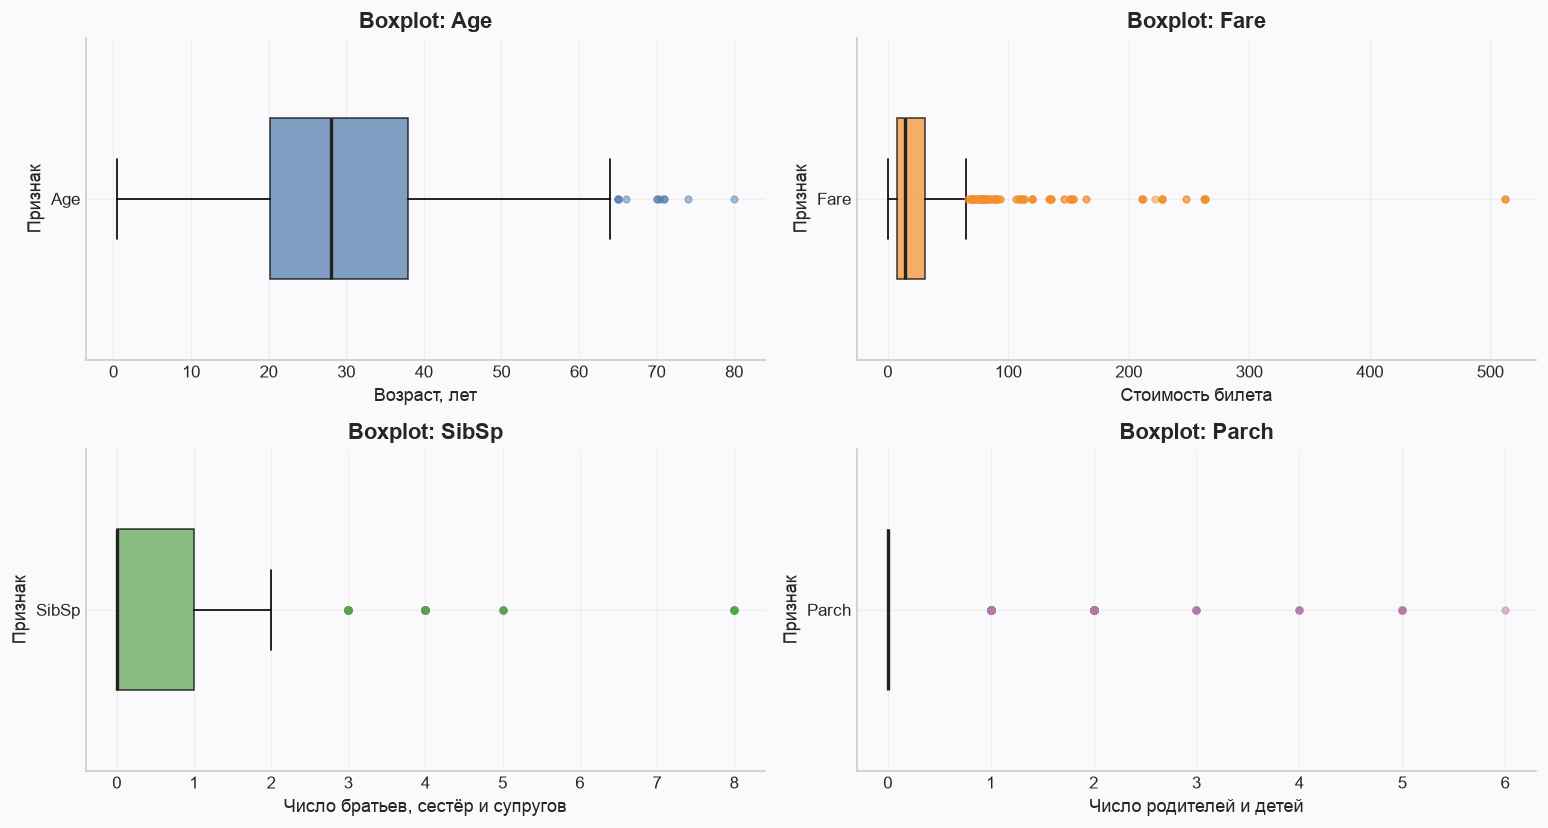

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

for ax, col, color in zip(axes.ravel(), numeric_cols, COLORS):
    ax.boxplot(
        df[col].dropna(),
        vert=False,
        patch_artist=True,
        widths=0.5,
        boxprops={"facecolor": color, "alpha": 0.7},
        medianprops={"color": "#222222", "linewidth": 2},
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": color,
            "markeredgecolor": color,
            "alpha": 0.45
        }
    )

    ax.set_title(f"Boxplot: {col}")
    ax.set_xlabel(labels[col])
    ax.set_ylabel("Признак")
    ax.set_yticks([1])
    ax.set_yticklabels([col])

fig.tight_layout()
plt.show()

Для Age правило IQR отмечает некоторые большие значения возраста, но пожилой пассажир не является ошибкой данных. У Fare много точек за верхней границей: дорогие билеты нужно проверить, а не удалять автоматически. Большие значения SibSp могут соответствовать большим семьям. Для Parch правило IQR мало подходит, потому что межквартильный размах равен нулю.

In [9]:
for col in category_cols:
    counts = df[col].value_counts(dropna=False)

    table = pd.DataFrame({
        "Количество": counts,
        "Доля, %": counts / len(df) * 100
    })

    table["Редкая, менее 5%"] = table["Доля, %"] < 5

    print(f"\nСтолбец: {col}")
    display(table.round(2))


Столбец: Pclass


,Количество,"Доля, %","Редкая, менее 5%"
Pclass,,,
3,491,55.11,False
1,216,24.24,False
2,184,20.65,False



Столбец: Sex


,Количество,"Доля, %","Редкая, менее 5%"
Sex,,,
male,577,64.76,False
female,314,35.24,False



Столбец: Embarked


,Количество,"Доля, %","Редкая, менее 5%"
Embarked,,,
S,644,72.28,False
C,168,18.86,False
Q,77,8.64,False
NaN,2,0.22,True


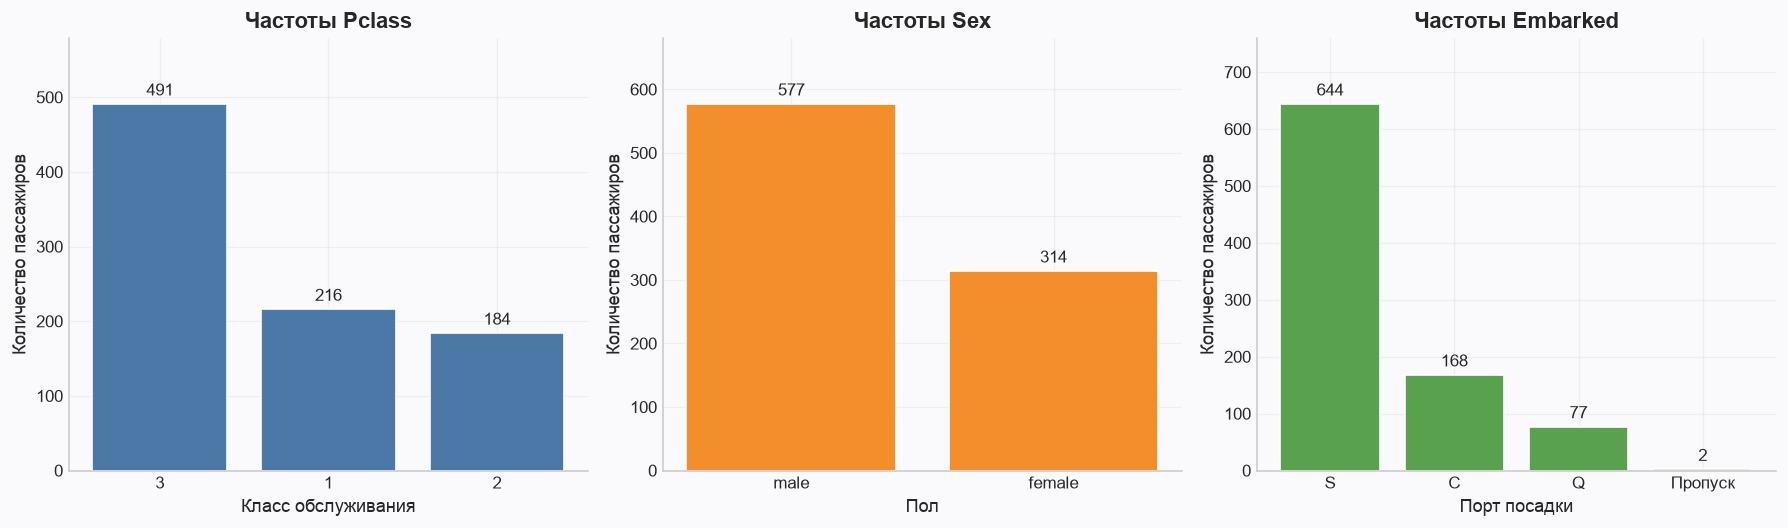

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

category_labels = {
    "Pclass": "Класс обслуживания",
    "Sex": "Пол",
    "Embarked": "Порт посадки"
}

for ax, col, color in zip(axes, category_cols, COLORS):
    values = df[col].astype("string").fillna("Пропуск")
    counts = values.value_counts()

    bars = ax.bar(
        counts.index.astype(str),
        counts.values,
        color=color,
        edgecolor="white"
    )

    ax.bar_label(bars, padding=3)
    ax.set_title(f"Частоты {col}")
    ax.set_xlabel(category_labels[col])
    ax.set_ylabel("Количество пассажиров")
    ax.set_ylim(0, counts.max() * 1.18)

fig.tight_layout()
plt.show()

В выборке больше всего пассажиров третьего класса. Мужчин больше, чем женщин. Большинство пассажиров с известным портом посадки сели в S. Среди известных значений Pclass, Sex и Embarked нет категорий с долей менее 5%. Два пропуска Embarked показаны отдельно.

In [11]:
for col in ["Name", "Ticket", "Cabin"]:
    counts = df[col].dropna().value_counts()
    rare_counts = counts[counts / len(df) < 0.05]

    print(f"\n{col}")
    print("Разных непустых значений:", len(counts))
    print("Значений, встречающихся только один раз:", int((counts == 1).sum()))
    print("Редких значений по порогу 5%:", len(rare_counts))

    display(counts.head(5).to_frame("Количество"))


Name
Разных непустых значений: 891
Значений, встречающихся только один раз: 891
Редких значений по порогу 5%: 891


,Количество
Name,
"Braund, Mr. Owen Harris",1
"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",1
"Heikkinen, Miss. Laina",1
"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1
"Allen, Mr. William Henry",1



Ticket
Разных непустых значений: 681
Значений, встречающихся только один раз: 547
Редких значений по порогу 5%: 681


,Количество
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6



Cabin
Разных непустых значений: 147
Значений, встречающихся только один раз: 101
Редких значений по порогу 5%: 147


,Количество
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F33,3
E101,3


В Name, Ticket и Cabin много разных значений. Имена рассматриваю как текст, а не как готовые категории для модели. Номера билетов и кают не стоит сразу превращать в сотни отдельных признаков. Позже можно проверить более общие признаки, например палубу по первой букве Cabin.

## Связи между числовыми признаками

,Age,Fare,SibSp,Parch
Age,1.000,0.096,-0.308,-0.189
Fare,0.096,1.000,0.160,0.216
SibSp,-0.308,0.160,1.000,0.415
Parch,-0.189,0.216,0.415,1.000


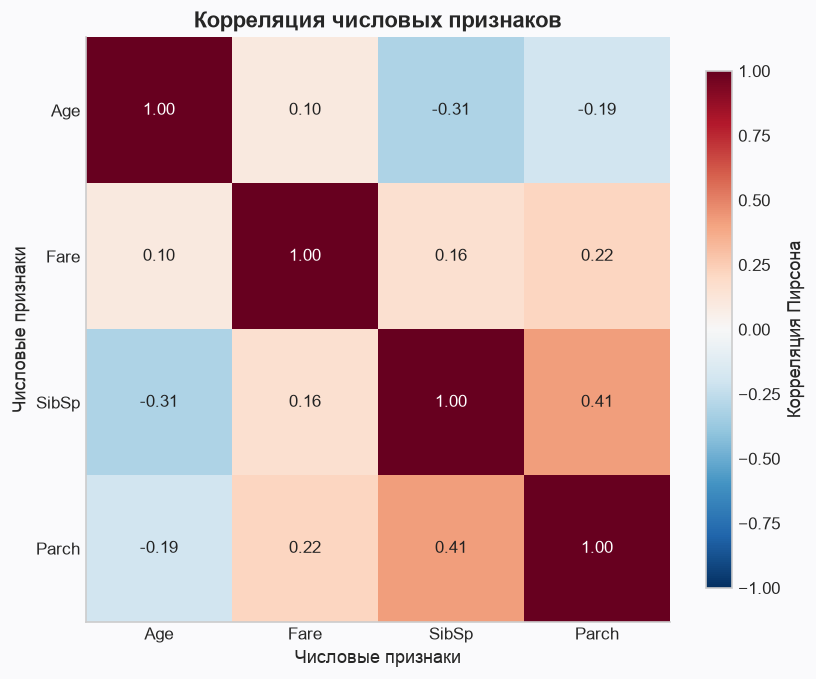

In [12]:
corr = df[numeric_cols].corr(method="pearson")

display(corr.round(3))

fig, ax = plt.subplots(figsize=(7, 6))

image = ax.imshow(
    corr,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

for i in range(len(corr)):
    for j in range(len(corr)):
        value = corr.iloc[i, j]
        ax.text(
            j, i, f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if abs(value) > 0.65 else "#222222"
        )

ax.set_title("Корреляция числовых признаков")
ax.set_xlabel("Числовые признаки")
ax.set_ylabel("Числовые признаки")
ax.grid(False)

colorbar = fig.colorbar(image, ax=ax, shrink=0.8)
colorbar.set_label("Корреляция Пирсона")

fig.tight_layout()
plt.show()

Самая заметная линейная связь среди выбранных числовых признаков находится между SibSp и Parch, примерно 0,41. Это можно связать с семейными поездками, но корреляция сама по себе не доказывает причинную связь. PassengerId исключён как идентификатор, Pclass рассматривается как порядковая категория, а Survived как целевой класс. Корреляции с Age рассчитаны по строкам, где возраст известен.

In [13]:
upper_mask = np.triu(
    np.ones(corr.shape, dtype=bool),
    k=1
)

pairs = corr.where(upper_mask).stack()
pairs = pairs.sort_values(
    key=lambda values: values.abs(),
    ascending=False
)

display(pairs.to_frame("Корреляция").round(3))

Корреляция
SibSp Parch       0.415
Age   SibSp      -0.308
Fare  Parch       0.216
Age   Parch      -0.189
Fare  SibSp       0.160
Age   Fare        0.096
      Age           NaN
Fare  Age           NaN
      Fare          NaN
SibSp Age           NaN
      Fare          NaN
      SibSp         NaN
Parch Age           NaN
      Fare          NaN
      SibSp         NaN
      Parch         NaN

Признаки для матрицы: ['SibSp', 'Parch', 'Age']


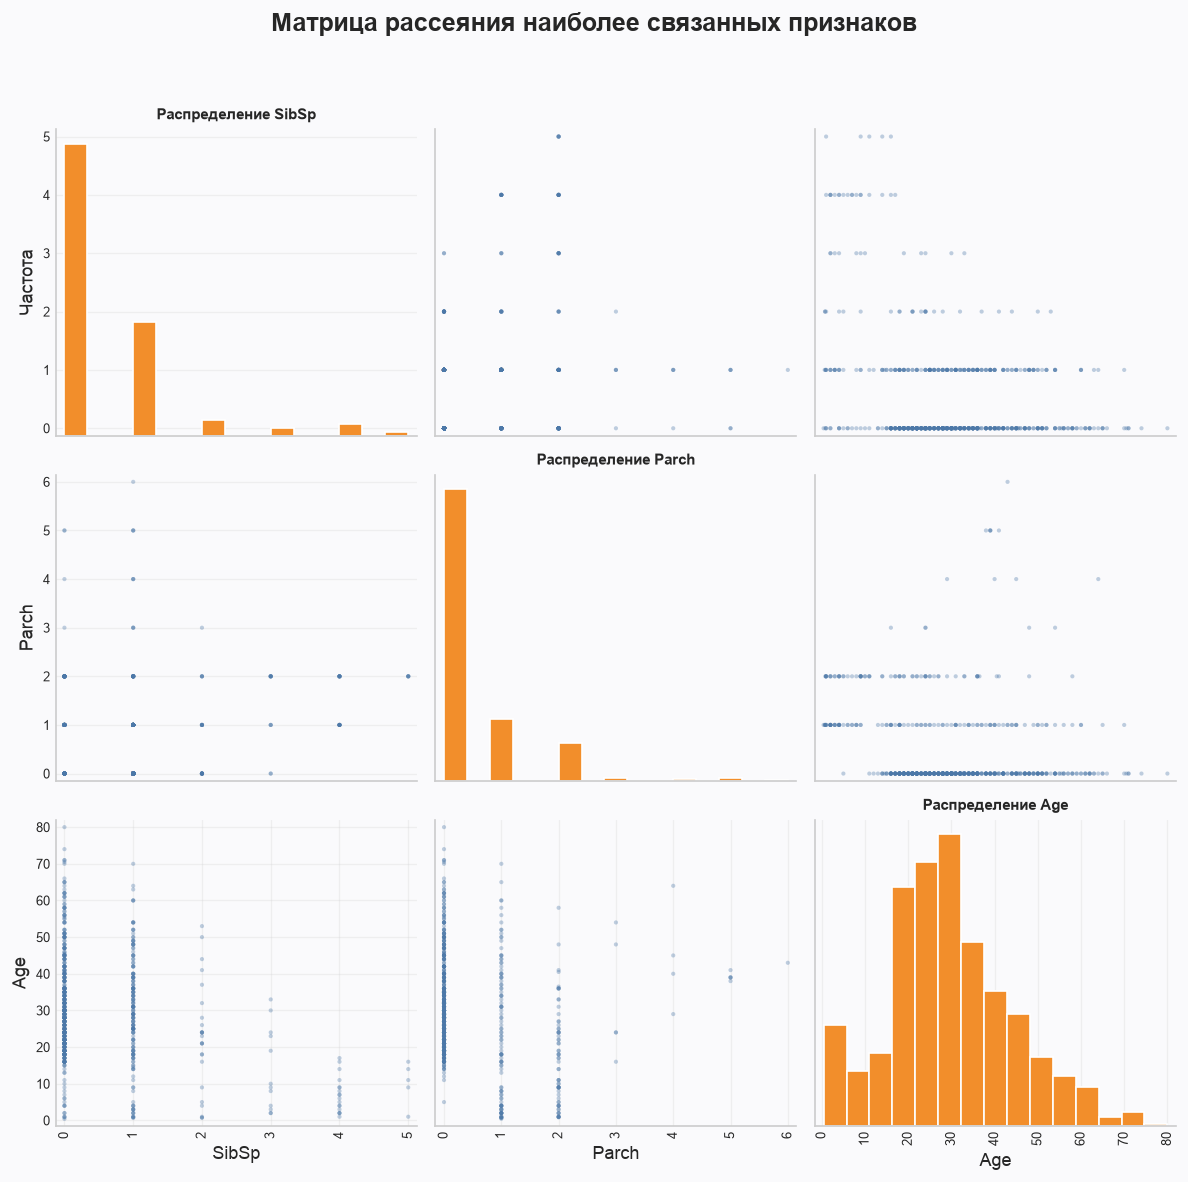

In [14]:
selected_cols = []

for first, second in pairs.head(2).index:
    for col in [first, second]:
        if col not in selected_cols:
            selected_cols.append(col)

print("Признаки для матрицы:", selected_cols)

plot_data = df[selected_cols].dropna()

axes = scatter_matrix(
    plot_data,
    figsize=(10, 10),
    diagonal="hist",
    color=COLORS[0],
    alpha=0.35,
    s=25,
    hist_kwds={
        "bins": 15,
        "color": COLORS[1],
        "edgecolor": "white"
    }
)

for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        if i == j:
            ax.set_title(f"Распределение {selected_cols[i]}", fontsize=9)
            ax.set_xlabel(selected_cols[i])
            ax.set_ylabel("Частота")
        else:
            ax.set_xlabel(selected_cols[j])
            ax.set_ylabel(selected_cols[i])

        ax.tick_params(labelsize=8)

fig = axes[0, 0].figure
fig.suptitle(
    "Матрица рассеяния наиболее связанных признаков",
    fontsize=15,
    fontweight="bold"
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

На диагонали видно, что SibSp и Parch чаще равны нулю, а Fare имеет длинный правый хвост. В паре SibSp и Parch точки образуют группы, потому что оба признака принимают целые значения. Для Fare и количества родственников есть общий положительный тренд, но разброс большой. Две пары из таблицы корреляций не дают оснований говорить о строгой зависимости или причинности.

,Количество,"Доля, %"
Survived,,
0,549,61.62
1,342,38.38


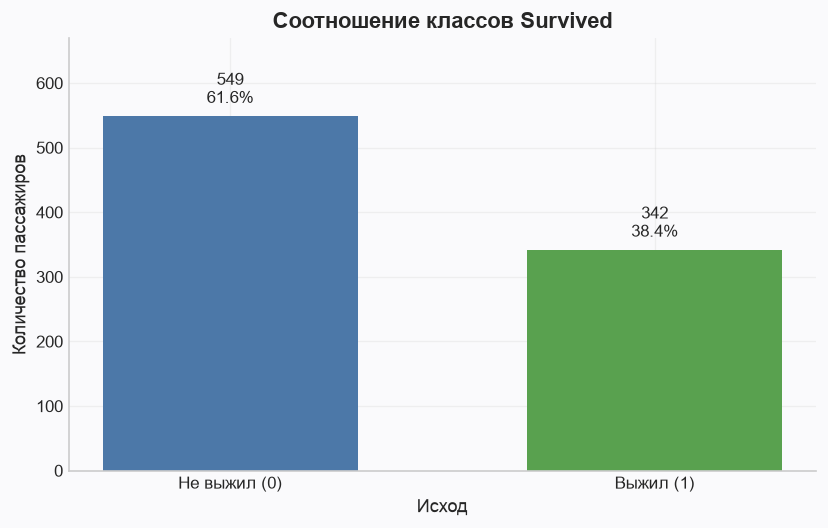

In [15]:
target_counts = df[target].value_counts().sort_index()

target_table = pd.DataFrame({
    "Количество": target_counts,
    "Доля, %": target_counts / len(df) * 100
})

display(target_table.round(2))

fig, ax = plt.subplots(figsize=(7, 4.5))

bars = ax.bar(
    ["Не выжил (0)", "Выжил (1)"],
    target_counts.values,
    color=[COLORS[0], COLORS[2]],
    width=0.6
)

bar_labels = [
    f"{count}\n{count / len(df):.1%}"
    for count in target_counts.values
]

ax.bar_label(bars, labels=bar_labels, padding=5)
ax.set_ylim(0, target_counts.max() * 1.22)
ax.set_title("Соотношение классов Survived")
ax.set_xlabel("Исход")
ax.set_ylabel("Количество пассажиров")

fig.tight_layout()
plt.show()

Классы распределены не поровну: примерно 62% относятся к классу 0 и 38% к классу 1. Дисбаланс умеренный. Модель, которая всегда отвечает 0, уже получит около 62% accuracy, поэтому одной этой метрики будет недостаточно. При разделении данных стоит сохранить доли классов и дополнительно оценивать precision, recall и F1.

## Проблемы данных и план подготовки

1. В Age отсутствуют 177 значений. На следующем занятии можно попробовать заполнение медианой и добавить признак отсутствующего возраста. Медиану нужно рассчитывать только на обучающей части.

2. В Cabin отсутствуют 687 значений, а в Embarked только 2. Для Cabin проверю вариант с признаком наличия каюты или палубой. Embarked можно заполнить самым частым портом, определённым по обучающей части.

3. По правилу 1,5 IQR у Fare отмечено 116 значений, у Age 11. Это кандидаты на проверку, а не доказанные ошибки. Для SibSp и Parch правило также отмечает большие семьи; у Parch IQR равен нулю. Автоматически удалять такие строки не буду.

4. Стоимость билета сильно скошена вправо. Можно сравнить исходный Fare и преобразование log1p, которое уменьшает влияние больших значений и допускает нулевую стоимость. Нулевые цены нужно отдельно проверить.

5. Name, Ticket и Cabin содержат много разных значений. PassengerId является идентификатором и не должен использоваться как обычный числовой признак. Для первой модели можно исключить имена и номера билетов, а остальные категории закодировать. Редкие категории объединять только при понятном обосновании.

6. В целевом столбце 549 значений класса 0 и 342 значения класса 1. При разделении данных нужно сохранить доли классов. Качество модели буду сравнивать с ответом по самому частому классу и оценивать не только по accuracy.

7. Перед подготовкой данных нужно выделить обучающую и проверочную части. Заполнение пропусков, масштабирование и подбор преобразований выполняются по обучающей части. Survived нельзя включать в признаки для предсказания самого Survived. Общие билеты и семейные связи тоже стоит учитывать: похожие связанные пассажиры в обеих частях могут сделать оценку слишком оптимистичной.

Полных повторов строк и повторов PassengerId не найдено. На этапе EDA строки не удалялись и пропуски не заполнялись.